# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train.

## Imports

In [ ]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import os

## Hyperparameter Definitions

In [ ]:
hidden_units = 512
n_layers = 2
n_epochs = 45
learning_rate = 0.0008
batch_size = 32
anneal = True
# Whether to anneal with our without warmup iterations:
warm = True
# minimal point of cosine annealing, zero is default:
eta_min = 0
# Number of warmup iterations before annealing:
t_0 = 9
# multiplicative factor with which to increase the number of
# epochs for each cosine annealing cycle, one is default:
t_mult = 1
# Degrees for random rotation of image training data:
degrees = 0
dropout = 0.2
weight_decay = 1e-4

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`!

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [105]:
# Defining initial training transforms based on a standard config:
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees),
    transforms.RandomCrop(32, padding = 4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # Utilizing the standard normalization parameters for CIFAR10:
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Defining initial testing transforms based on a standard config:
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Defining initial testing transforms based on a standard config:
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Create training set and define training dataloader
train_dataset_whole = torchvision.datasets.CIFAR10(
    # This may need to be adapted, for grading purposes, project folder name
    # is: '/udacity_machine_learning_with_pytorch_project_2'.
    root = os.getcwd(),
    train = True,
    download = True,
    transform = train_transforms
)

# Create a test set and define test dataloader; CIFAR10 provides the testing
# data set, so no need to manually split:
test_dataset = torchvision.datasets.CIFAR10(
    # This may need to be adapted, for grading purposes, project folder name
    # is: '/udacity_machine_learning_with_pytorch_project_2'.
    root = os.getcwd(),
    train = False,
    download = True,
    transform = test_transforms
)

# For training, perform a random split with the whole training dataset:
train_size = int(len(train_dataset_whole) * 0.9)
val_size = len(train_dataset_whole) - train_size

## Generate a random seed for reproducibility of the data sets:
torch.manual_seed(42)

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset_whole,
                                                           [
                                                               train_size,
                                                               val_size
                                                           ])

## Lastly, manually override the 'transforms' attribute of the new validation
## dataset, to ensure it doesn't perform the same data augmentation as the
## training set:
val_dataset.transforms = val_transforms

# Ensure the split datasets capture all 60,000 images in CIFAR10:
print('Total images between the datasets:',
      len(train_dataset) + len(val_dataset) + len(test_dataset))

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size = batch_size,
    shuffle = False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False
)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Total images between the datasets: 60000


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [106]:
print('Number of images in the training data:', len(train_loader.dataset))
# Get the next batch from the training data loader:
train_features, train_labels = next(iter(train_loader))
print('Shape of a single batch from the training loader:')
print(f'Feature batch shape: {train_features.shape}')
print(f'Label batch shape, each representing a true image label: {train_labels.shape}')

Number of images in the training data: 45000
Shape of a single batch from the training loader:
Feature batch shape: torch.Size([32, 3, 32, 32])
Label batch shape, each representing a true image label: torch.Size([32])


In [107]:
def show5(img_loader):
    dataiter = iter(img_loader)

    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])

        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

cat


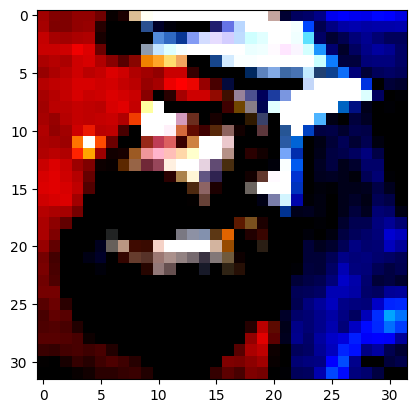

ship


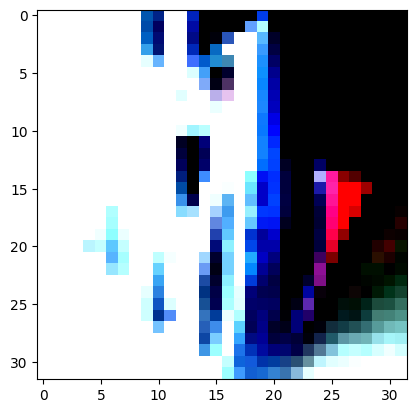

ship


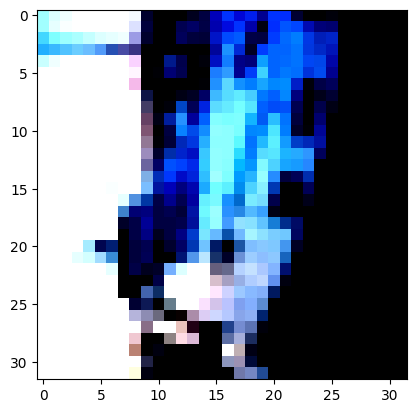

plane


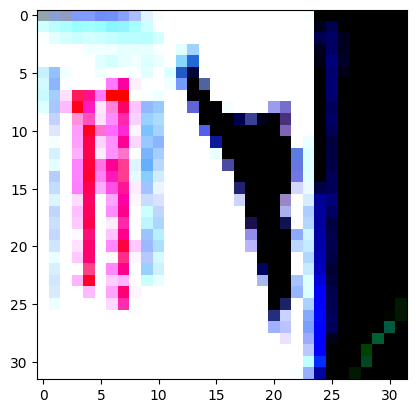

frog


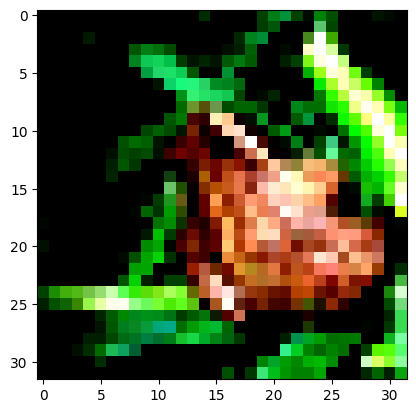

In [108]:
# Explore data
show5(test_loader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [109]:
class BILSTM_CIFAR10(nn.Module):
    '''
    Defines the image classification model.
    '''
    def __init__(self, input_size = 3 * 32,
                 hidden_units = 768,
                 output_size = 10,
                 n_layers = 2,
                 dropout = 0.2
                 ):
        '''
        Instantiator for the BILSTM to CIFAR10 network.

        Args:
            input_size (int): Number of inputs (1-D image row vectors) to input
            to the BILSTM.
            hidden_units (int): Number of hidden units with which to capture
            feature relationships. Defaulted to 768, to ensure capture of
            high-level features.
            output_size (int): Number of classes on which CIFAR10 evaluates
            results (default to 10)
            n_layers (int): Number of hidden layers to insert into this BILSTM
            to CIFAR10 network. 2 is generally recommended, for advanced image
            classification.
        '''
        super().__init__()
        self.hidden_units = hidden_units
        self.n_layers = n_layers

        # Here, input size represents the batch/time step with respect to the
        # size of input 'x', hidden units is the feature space length of the
        # succeeding hidden layers, and the number of layers is how many
        # iterations of the total number of sequences in the input 'x':
        self.bilstm = nn.LSTM(input_size, hidden_units, n_layers,
                              bidirectional = True, batch_first = True,
                              dropout = dropout)
        # Because both backward and forward hidden state is maintained,
        # the hidden units must be scaled by two, to ensure permissible
        # matrix multiplication when passed to the fully-connected linear
        # layer.
        self.fc = nn.Linear(hidden_units * 2, 10)
        # Using layer normalization prior to activation, as it normalizes with
        # respect to time steps, as opposed to a more traditional batching.
        # Also ensuring layer normalization layer matches hidden state + hidden
        # units dimension shape:
        self.layer_norm = nn.LayerNorm(hidden_units * 2)

    def temp_hide(self, hidden_state):
        print(hidden_state.shape)

    def forward(self, x):
        '''
        Instance method that defines the forward pass through the network
        being trained.

        Args:
            x (torch.float32): A piece of data (a batch of images, in this case)
            to be fed forward through the network.

        Returns:
            A PyTorch tensor containing the log-probabilities of the image
            prediction, with respect to the CIFAR10 labels.
        '''

        # Must reshape the input 'x' for sequencing through BILSTM, with the
        # following configuration: (batch size, sequence length [because LSTM
        # generally calculates using 32-pixel row vectors], input size/
        # dimensions[3 channels on a 32-pixel image grid])) Configured this
        # way, due to 'batch_first' parameter set to 'True' in the attribute
        # that defines the BILSTM; this makes it easier to pass to the LSTM:
        x = x.view(x.size(0), 32, 3 * 32)

        # Send the input through the BILSTM. In the case of traditional LSTM,
        # the extracted 'output' tensor could be used to extract the final
        # hidden state. However, in the case of BiDirectional LSTM, the
        # extracted hidden state tensors 'h_s' are used to extract the final
        # hidden state. The shape of 'h_s' is: (n_layers * 2, batch size,
        # hunits):
        output, (h_s, c_s) = self.bilstm(x)

        # Ensure the utilized hidden and cell states are sent to the GPU:
        h_s = h_s.cuda()
        c_s = c_s.cuda()

        # Extract the hidden state to be passed to the next time step. Upon
        # conclusion of the BILSTM layer, the pertinent final forward and
        # backward hidden states are stored in the final two elements of the
        # first dimension. In addition, in order to get a discrete logit value
        # for each batch's image, the tensors are concatenated about the
        # first dimension, which is with respect to the batch images. This will
        # effectively map both hidden states to each image in the batch:
        f_hidden = torch.cat((h_s[-2, :, :], h_s[-1, :, :]), dim = 1)

        # Because the final concatenation fully concatenated about the
        # final two hidden states of each image in the batch,
        # the number of hidden units is consequentally multiplied by two for
        # passing to the next layer, giving 'f_hidden' a final output shape of:
        # (n_layers * 2, batch size, 2 * hidden_units):
        return F.log_softmax(self.fc(self.layer_norm(f_hidden)), dim = 1)

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [110]:
bilstm_clf = BILSTM_CIFAR10(
    # CIFAR10 are trained on 32x32 RGB pixel images
    input_size = 3 * 32,
    hidden_units = hidden_units,
    output_size = 10,
    n_layers = n_layers,
    dropout = dropout
)

# Instantiate the GPU device, and then send the model to the GPU, if available:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilstm_clf.to(device)

criterion = nn.NLLLoss()

# Potential vanishing gradients near the end of training noticed when
# plotting metrics, so experimenting with optimizer:
optimizer = torch.optim.Adam(bilstm_clf.parameters(),
                                lr = learning_rate,
                                weight_decay = weight_decay)

# If requested, initialize a cosine annealing scheduler:
if anneal:
    if warm:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            # Observe plotting metrics to estimate best value for warm-up
            # iterations:
            T_0 = t_0,
            T_mult = t_mult,
            eta_min = eta_min
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max = n_epochs
        )

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch.
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [111]:
# In case of error handling, reset the model to training mode, before
# re-iterating training loop
bilstm_clf.train()

# Initialize lists for plotting the metrics after training/validation:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(n_epochs):
    # Initialize the validation rate:
    val_every = 234
    # Initialize the running training loss and accuracy:
    running_loss = 0
    running_accuracy = 0

    # Iterate through the batches generated from the train loader, sending
    # batches of images and labels to the GPU. Begin enumeration of train
    # loader at one, to align with batch iteration:
    for i, (images, labels) in enumerate(train_loader, 1):
        images = images.cuda()
        labels = labels.cuda()

        # Do a forward pass through the network, and calculate the training
        # loss for this batch using the criterion:
        logps = bilstm_clf(images)
        loss = criterion(logps, labels)

        # Zero the gradients, for this time step/batch:
        optimizer.zero_grad()
        # Backward propagate:
        loss.backward()
        # Step the optimizer through for weight adjustments:
        optimizer.step()

        # Add the training loss item to the running loss:
        running_loss += loss.item()

        # Calculate and add the training accuracy for this time step/batch:
        ps = torch.exp(logps)
        top_ps, top_class = ps.topk(1, dim = 1)
        # Compare the top classes for each image classified with
        # the true image labels, ensuring that the 'label' and
        # 'top_class' tensors have the same shape:
        equality = top_class == labels.view(*top_class.shape)
        # Aggregate the mean result of the class-label comparison:
        running_accuracy += torch.mean(equality.type(torch.FloatTensor)).item()

        if i % val_every == 0:
            # Set the model to evaluation mode:
            bilstm_clf.eval()

            # Initialize validation loss and accuracy:
            val_loss = 0
            val_accuracy = 0

            # Turn off gradient calculation:
            with torch.no_grad():
                # Load in images and labels from the validation set, then
                # sending them to the GPU being utilized:
                for images, labels in val_loader:
                    images, labels = images.cuda(), labels.cuda()

                    # Do a forward pass through the network, and calculate
                    # the validation loss for this batch using the criterion:
                    logps = bilstm_clf(images)
                    loss = criterion(logps, labels)

                    # Add the item from the backpropagation loss to the
                    # validation loss:
                    val_loss += loss.item()
                    # Convert the outputted log probabilities back using
                    # 'torch.exp':
                    ps = torch.exp(logps)
                    # Calculate the validation accuracy, using the 'ps' tensor:
                    top_ps, top_class = ps.topk(1, dim = 1)
                    # Compare the top classes for each image classified with
                    # the true image labels, ensuring that the 'label' and
                    # 'top_class' tensors have the same shape:
                    equality = top_class == labels.view(*top_class.shape)
                    # Aggregate the mean result of the class-label comparison:
                    val_accuracy += torch.mean(equality.type(
                        torch.FloatTensor)).item()

                # Store the total training loss and accuracy:
                total_train_loss = running_loss / val_every
                total_train_accuracy = running_accuracy / val_every

                # Upon completion of validation, print the training and
                # validation metrics, aggregated over 234 batches:
                print(f'Epoch {epoch + 1} of {n_epochs}:')
                print(
                    f'Training loss, after {val_every} more batches: ' +
                    f'{total_train_loss:.3f}'
                )
                print(
                    f'Training accuracy, after {val_every} more batches: ' +
                    f'{total_train_accuracy:.2%}'
                )

                ## Store the total validation loss and accuracy:
                total_val_loss = val_loss / len(val_loader)
                total_val_accuracy = val_accuracy / len(val_loader)

                print(
                    f'Total validation loss: {total_val_loss:.3f}'
                )
                print(
                    f'Total validation accuracy: ' +
                    f'{total_val_accuracy:.2%}'
                )

                ## Append training and validation metrics to plotting lists:
                train_losses.append(total_train_loss)
                val_losses.append(total_val_loss)
                train_accuracies.append(total_train_accuracy)
                val_accuracies.append(total_val_accuracy)

                # Reset the running training loss and accuracy, for accumulation
                # on the next n batches:
                running_loss = running_accuracy = 0
                # Set the model back to training mode:
                bilstm_clf.train()
    # If annealing was requested, take a step with the
    # learning rate scheduler, upon conclusion of each
    # epoch:
    if anneal:
        scheduler.step()

Epoch 1 of 45:
Training loss, after 234 more batches: 2.199
Training accuracy, after 234 more batches: 21.73%
Total validation loss: 2.012
Total validation accuracy: 25.00%
Epoch 1 of 45:
Training loss, after 234 more batches: 1.938
Training accuracy, after 234 more batches: 28.90%
Total validation loss: 1.903
Total validation accuracy: 31.29%
Epoch 1 of 45:
Training loss, after 234 more batches: 1.839
Training accuracy, after 234 more batches: 32.69%
Total validation loss: 1.765
Total validation accuracy: 34.77%
Epoch 1 of 45:
Training loss, after 234 more batches: 1.763
Training accuracy, after 234 more batches: 35.62%
Total validation loss: 1.736
Total validation accuracy: 36.25%
Epoch 1 of 45:
Training loss, after 234 more batches: 1.726
Training accuracy, after 234 more batches: 36.32%
Total validation loss: 1.727
Total validation accuracy: 36.68%
Epoch 1 of 45:
Training loss, after 234 more batches: 1.678
Training accuracy, after 234 more batches: 38.84%
Total validation loss: 1.

Plot the training loss (and validation loss/accuracy, if recorded).

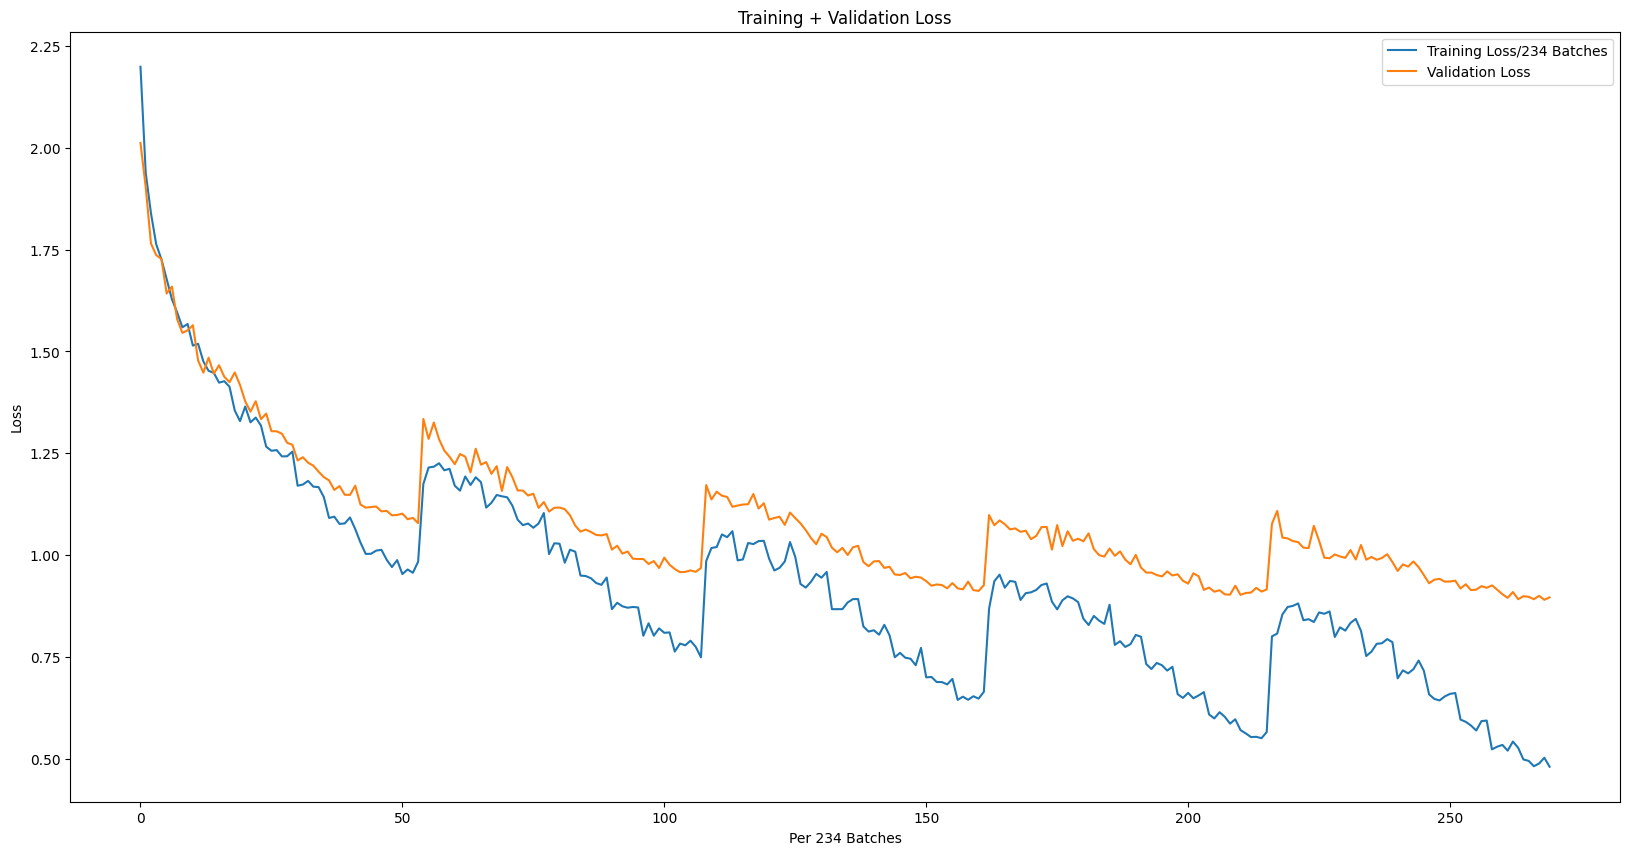

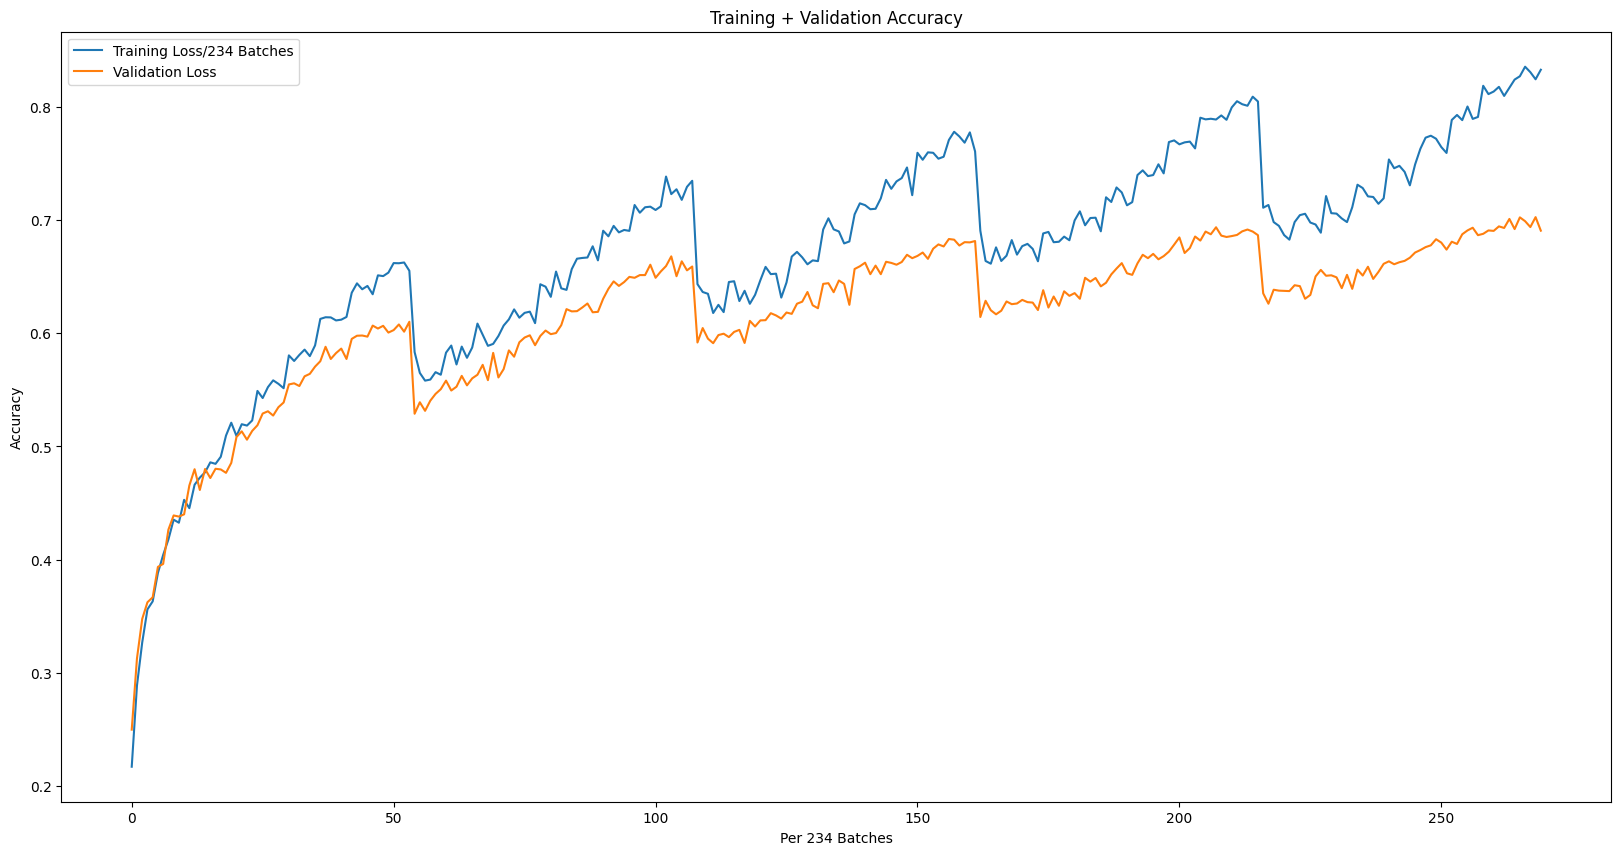

In [112]:
plt.figure(figsize = (20, 10))
plt.plot(range(len(train_losses)), train_losses,
# Figure for training and validation losses:
         label = f'Training Loss/{val_every} Batches')
plt.plot(range(len(val_losses)), val_losses,
         label = 'Validation Loss' )
plt.title('Training + Validation Loss')
plt.xlabel(f'Per {val_every} Batches')
plt.ylabel(f'Loss')
plt.legend()
plt.show()

# Figure for training and validation accuracies:
plt.figure(figsize = (20, 10))
plt.plot(range(len(train_accuracies)), train_accuracies,
         label = f'Training Loss/{val_every} Batches')
plt.plot(range(len(val_accuracies)), val_accuracies,
         label = 'Validation Loss' )
plt.title('Training + Validation Accuracy')
plt.xlabel(f'Per {val_every} Batches')
plt.ylabel(f'Accuracy')
plt.legend()
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction.

If your accuracy is over 70%, great work!
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [113]:
# Set the model to evaluation mode:
bilstm_clf.eval()

# Initialize testing loss and accuracy:
test_loss = 0
test_accuracy = 0

# Turn off gradient calculations:
with torch.no_grad():
    # Load in images and labels from the testing set, then
    # sending them to the GPU being utilized:
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()

        # Do a forward pass through the network, and calculate
        # the test loss for this batch using the criterion:
        logps = bilstm_clf(images)
        loss = criterion(logps, labels)

        # Add the item from the backpropagation loss to the
        # test loss:
        test_loss += loss.item()
        # Convert the outputted log probabilities back using
        # 'torch.exp':
        ps = torch.exp(logps)
        # Calculate the test accuracy, using the 'ps' tensor:
        top_ps, top_class = ps.topk(1, dim = 1)
        # Compare the top classes for each image classified with
        # the true image labels, ensuring that the 'label' and
        # 'top_class' tensors have the same shape:
        equality = top_class == labels.view(*top_class.shape)
        # Aggregate the mean result of the class-label comparison:
        test_accuracy += torch.mean(equality.type(
            torch.FloatTensor)).item()

    # Store the total test loss and accuracy:
    total_test_loss = test_loss / len(test_loader)
    total_test_accuracy = test_accuracy / len(test_loader)

    # Display the resulting total test loss and accuracy:
    print(
        f'Total test loss: {total_test_loss:.3f}'
    )
    print(
        f'Total test accuracy: ' +
        f'{total_test_accuracy:.2%}'
    )

Total test loss: 0.889
Total test accuracy: 70.05%


## Saving your model
Using `torch.save`, save your model for future loading.

In [114]:
# This may need to be adapted, for grading purposes, project folder name
# is: '/udacity_machine_learning_with_pytorch_project_2'.
torch.save(bilstm_clf.state_dict(), os.getcwd() + '/cifar10_bilstm.pth')

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

For this image classification task on the standard CIFAR10 10-class dataset, I decided to take on a challenge of training a less traditional Recurrent Neural Network (RNN), specifically a bi-directional LSTM, to interact with and understand the architecture a little better. Though RNNs can be utilized for the task put forth here, they require an exhaustive amount of tuning of hyperparameters; in addition, RNNs have found to be more successful in combination with Convolutional Neural Networks (CNNs), with many applications in time series and sequence-based media analysis/classification.

After thorough model adjustment and tuning, the highest test accuracy obtained was just around the 70% goal threshold. If constrained to use of an RNN architecture, if given more time for analysis and ability to utilize advanced hyperparameter tuning frameworks, I would recommend going forward with building the image classifier in-house. In any other case, the image classifier can most certainly be built in-house, especially if pre-trained deep learning models with many blocks/layers of convolutional calculations are utilized.